In [ ]:
from __future__ import division
from google.colab import drive
drive.mount('/content/gdrive')

Mounted at /content/gdrive


In [ ]:
import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import warnings
warnings.filterwarnings('ignore')


In [ ]:
cd cd /content/drive/MyDrive/Machine learning 2024/Notebooks - ANN - DNN/10.S RNN & LSTM/RNN - LSTM - GRU

/content/gdrive/MyDrive/Machine learning 2024/Notebooks - ANN - DNN/10.S RNN & LSTM/Amazon Stock Price prediction


# Read Data

In [ ]:
df=pd.read_csv('prices.csv')

# Describe the data

In [ ]:
df.head()

,date,symbol,open,close,low,high,volume
0,1/5/2016 0:00,WLTW,123.430000,125.839996,122.309998,126.250000,2163600
1,1/6/2016 0:00,WLTW,125.239998,119.980003,119.940002,125.540001,2386400
2,1/7/2016 0:00,WLTW,116.379997,114.949997,114.930000,119.739998,2489500
3,1/8/2016 0:00,WLTW,115.480003,116.620003,113.500000,117.440002,2006300
4,1/11/2016 0:00,WLTW,117.010002,114.970001,114.089996,117.330002,1408600


# Check for Null Values

In [ ]:
df.isnull().sum()

,0
date,0
symbol,0
open,0
close,0
low,0
high,0
volume,0


***No Null values in the entire dataset***

# Check Datatype of the features

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 851264 entries, 0 to 851263
Data columns (total 7 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   date    851264 non-null  object 
 1   symbol  851264 non-null  object 
 2   open    851264 non-null  float64
 3   close   851264 non-null  float64
 4   low     851264 non-null  float64
 5   high    851264 non-null  float64
 6   volume  851264 non-null  int64  
dtypes: float64(4), int64(1), object(2)
memory usage: 45.5+ MB


***Date & Symbol are in object datatype and rest are float datatype***

In [ ]:
df.describe()

,open,close,low,high,volume
count,851264.000000,851264.000000,851264.000000,851264.000000,8.512640e+05
mean,70.836986,70.857109,70.118414,71.543476,5.415113e+06
std,83.695876,83.689686,82.877294,84.465504,1.249468e+07
min,0.850000,0.860000,0.830000,0.880000,0.000000e+00
25%,33.840000,33.849998,33.480000,34.189999,1.221500e+06
50%,52.770000,52.799999,52.230000,53.310001,2.476250e+06
75%,79.879997,79.889999,79.110001,80.610001,5.222500e+06
max,1584.439941,1578.130005,1549.939941,1600.930054,8.596434e+08


# Dataframe shape

In [ ]:
df.shape

(851264, 7)

In [ ]:
df['symbol'].nunique()

501

***There are 501 symbols in the datasets and in total there are 851264 rows with 7 columns***  
***Data set is good for analysis. however, since there are many company details are there. we will sample it with one Company***

# Sampling AMAZON from the dataset
GOOGL is the NYSE stock symbol for Google stocks. let us take that as a sample for our analysis.

In [ ]:
df1=df[df['symbol']=='AMZN']

In [ ]:
df1.head()

,date,symbol,open,close,low,high,volume
284,1/4/2010,AMZN,136.250000,133.899994,133.139999,136.610001,7599900
751,1/5/2010,AMZN,133.429993,134.690002,131.809998,135.479996,8851900
1219,1/6/2010,AMZN,134.600006,132.250000,131.649994,134.729996,7178800
1687,1/7/2010,AMZN,132.009995,130.000000,128.800003,132.320007,11030200
2155,1/8/2010,AMZN,130.559998,133.520004,129.029999,133.679993,9830500


In [ ]:
df1.describe()

,open,close,low,high,volume
count,1762.000000,1762.000000,1762.000000,1762.000000,1.762000e+03
mean,337.875664,337.899058,333.969688,341.464438,4.607596e+06
std,189.294231,189.109339,187.654696,190.525796,3.091557e+06
min,105.930000,108.610001,105.800003,111.290001,9.844000e+05
25%,192.962494,193.377506,190.284997,195.532501,2.741550e+06
50%,282.500000,282.915008,279.869995,285.074997,3.890700e+06
75%,398.425003,398.014999,393.799988,402.082496,5.384450e+06
max,845.789978,844.359985,840.599976,847.210022,4.242110e+07


In [ ]:
df1.shape

(1762, 7)

In [ ]:
df1['date']=pd.to_datetime(df1['date'])

In [ ]:
print("Minimum date value : {}".format(df1['date'].min()))
print("Maximum date value : {}".format(df1['date'].max()))

Minimum date value : 2010-01-04 00:00:00
Maximum date value : 2016-12-30 00:00:00


***we have around 6 years of data***

# EDA

Text(0.5, 1.0, 'AMAZON Stock value changes since 2010')

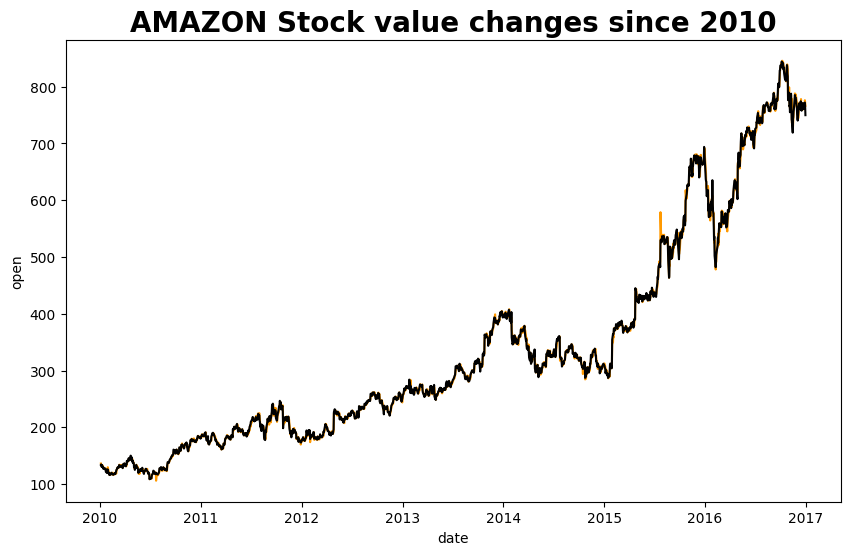

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
colors = ['#FF9900','#000000']

fig=plt.figure(figsize=(10,6))
ax=sns.lineplot(data=df1, x='date',y='open', color=colors[0])
ax=sns.lineplot(data=df1, x='date',y='close', color=colors[1]);

plt.title("AMAZON Stock value changes since 2010", size=20, weight='bold')

# Categorical feature analysis  
** There is no categorical feature other than Symbol. as we have taken the Google stock as sample data, we will drop the Symbol feature.

In [ ]:
df1.drop(['symbol'], axis=1, inplace=True)

In [ ]:
df1.corr()['close']

,close
date,0.908957
open,0.999581
close,1.000000
low,0.999832
high,0.999811
volume,-0.238560


# Hypothesis test to find the Normality in the Dataset

# Correlation

<Axes: >

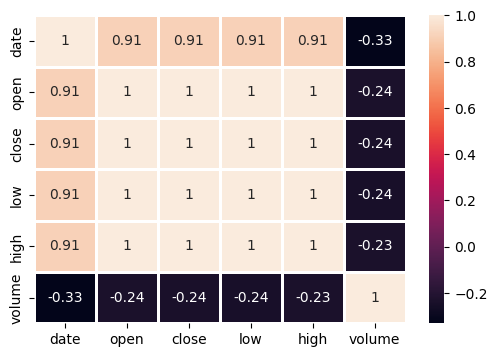

In [ ]:
fig=plt.figure(figsize=(6,4))
sns.heatmap(df1.corr(), annot=True , linecolor='white', linewidth=2 )

***feature Open, high, low are highly correlated to Target feature Close. we can use either one of the feature for prediction to avoid multicollinearity***

# Try with LSTM

In [ ]:
X=df1[['close']]

#split the dataset and normalize

training_set = X.iloc[:1300].values
test_set = X.iloc[1300:].values

print(training_set.shape)
print(test_set.shape)

(1300, 1)
(462, 1)


In [ ]:
training_set[:10]

array([[133.899994],
       [134.690002],
       [132.25    ],
       [130.      ],
       [133.520004],
       [130.309998],
       [127.349998],
       [129.110001],
       [127.349998],
       [127.139999]])

In [ ]:
test_set[:10]

array([[387.829987],
       [380.089996],
       [378.559998],
       [369.51001 ],
       [366.369995],
       [374.23999 ],
       [370.579987],
       [373.350006],
       [371.920013],
       [375.140015]])

In [ ]:
# Feature Scaling
from sklearn.preprocessing import MinMaxScaler
sc = MinMaxScaler(feature_range = (0, 1))
training_set_scaled = sc.fit_transform(training_set)
test_set_scaled=sc.transform(test_set)

print(training_set_scaled.shape)
print(test_set_scaled.shape)

(1300, 1)
(462, 1)


In [ ]:
length=100
X_train = []
y_train = []
for i in range(length, len(training_set)):  # i=100, lenght=100 --> 0 - 99
    X_train.append(training_set_scaled[i-length:i, 0])  #100
    y_train.append(training_set_scaled[i, 0])  #100
    print(i-length, " i-1 ", i-1, " i ", i)

0  i-1  99  i  100
1  i-1  100  i  101
2  i-1  101  i  102
3  i-1  102  i  103
4  i-1  103  i  104
5  i-1  104  i  105
6  i-1  105  i  106
7  i-1  106  i  107
8  i-1  107  i  108
9  i-1  108  i  109
10  i-1  109  i  110
11  i-1  110  i  111
12  i-1  111  i  112
13  i-1  112  i  113
14  i-1  113  i  114
15  i-1  114  i  115
16  i-1  115  i  116
17  i-1  116  i  117
18  i-1  117  i  118
19  i-1  118  i  119
20  i-1  119  i  120
21  i-1  120  i  121
22  i-1  121  i  122
23  i-1  122  i  123
24  i-1  123  i  124
25  i-1  124  i  125
26  i-1  125  i  126
27  i-1  126  i  127
28  i-1  127  i  128
29  i-1  128  i  129
30  i-1  129  i  130
31  i-1  130  i  131
32  i-1  131  i  132
33  i-1  132  i  133
34  i-1  133  i  134
35  i-1  134  i  135
36  i-1  135  i  136
37  i-1  136  i  137
38  i-1  137  i  138
39  i-1  138  i  139
40  i-1  139  i  140
41  i-1  140  i  141
42  i-1  141  i  142
43  i-1  142  i  143
44  i-1  143  i  144
45  i-1  144  i  145
46  i-1  145  i  146
47  i-1  146  i  147
48 

In [ ]:
X_train, y_train = np.array(X_train), np.array(y_train)

In [ ]:
print(X_train.shape)
print(y_train.shape)

(1200, 100)
(1200,)


In [ ]:
print(X_train[0])

[0.08474063 0.08738776 0.0792119  0.0716727  0.08346738 0.07271143
 0.06279318 0.06869053 0.06279318 0.06208953]


In [ ]:
X_test = []
y_test = []
for i in range(length, len(test_set)):
    X_test.append(test_set_scaled[i-length:i, 0])
    y_test.append(test_set_scaled[i, 0])

In [ ]:
X_test, y_test = np.array(X_test), np.array(y_test)

In [ ]:
X_train_LSTM = np.reshape(X_train, (X_train.shape[0], X_train.shape[1], 1))
X_test_LSTM = np.reshape(X_test, (X_test.shape[0], X_test.shape[1], 1))

In [ ]:
X_train.shape

(1200, 100, 1)

In [ ]:
X_train[0][:10]

array([[0.08474063],
       [0.08738776],
       [0.0792119 ],
       [0.0716727 ],
       [0.08346738],
       [0.07271143],
       [0.06279318],
       [0.06869053],
       [0.06279318],
       [0.06208953]])

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, LSTM, Dropout
model = Sequential()
#Adding the first LSTM layer and some Dropout regularisation
model.add(LSTM(units = 50, return_sequences = True, input_shape = (X_train.shape[1], 1)))
model.add(Dropout(0.2))
# Adding a second LSTM layer and some Dropout regularisation
model.add(LSTM(units = 50, return_sequences = True))
model.add(Dropout(0.2))
# Adding a third LSTM layer and some Dropout regularisation
model.add(LSTM(units = 50, return_sequences = True))
model.add(Dropout(0.2))
# Adding a fourth LSTM layer and some Dropout regularisation
model.add(LSTM(units = 50))
model.add(Dropout(0.2))
# Adding the output layer
model.add(Dense(units = 1))

# Compiling the RNN
model.compile(optimizer = 'adam', loss = 'mean_squared_error')

# Fitting the RNN to the Training set
model.fit(X_train, y_train, validation_data=(X_test,y_test),epochs = 100, batch_size = 32)

Epoch 1/100
38/38 ━━━━━━━━━━━━━━━━━━━━ 19s 337ms/step - loss: 0.1060 - val_loss: 0.2912
Epoch 2/100
38/38 ━━━━━━━━━━━━━━━━━━━━ 10s 256ms/step - loss: 0.0071 - val_loss: 0.3279
Epoch 3/100
38/38 ━━━━━━━━━━━━━━━━━━━━ 8s 191ms/step - loss: 0.0056 - val_loss: 0.2628
Epoch 4/100
38/38 ━━━━━━━━━━━━━━━━━━━━ 12s 226ms/step - loss: 0.0057 - val_loss: 0.1960
Epoch 5/100
38/38 ━━━━━━━━━━━━━━━━━━━━ 11s 243ms/step - loss: 0.0056 - val_loss: 0.1937
Epoch 6/100
38/38 ━━━━━━━━━━━━━━━━━━━━ 7s 189ms/step - loss: 0.0057 - val_loss: 0.1809
Epoch 7/100
38/38 ━━━━━━━━━━━━━━━━━━━━ 12s 222ms/step - loss: 0.0046 - val_loss: 0.1763
Epoch 8/100
38/38 ━━━━━━━━━━━━━━━━━━━━ 9s 236ms/step - loss: 0.0059 - val_loss: 0.1825
Epoch 9/100
38/38 ━━━━━━━━━━━━━━━━━━━━ 9s 192ms/step - loss: 0.0050 - val_loss: 0.1959
Epoch 10/100
38/38 ━━━━━━━━━━━━━━━━━━━━ 11s 221ms/step - loss: 0.0048 - val_loss: 0.1540
Epoch 11/100
38/38 ━━━━━━━━━━━━━━━━━━━━ 9s 250ms/step - loss: 0.0048 - val_loss: 0.2272
Epoch 12/100
38/38 ━━━━━━━━━━━━━━━━

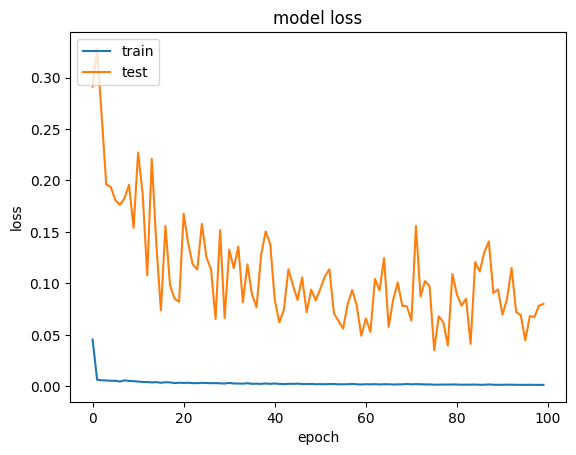

In [ ]:
# prompt: plot the graph for loass and val_loss

import matplotlib.pyplot as plt
plt.plot(model.history.history['loss'])
plt.plot(model.history.history['val_loss'])
plt.title('model loss')
plt.ylabel('loss')
plt.xlabel('epoch')
plt.legend(['train', 'test'], loc='upper left')
plt.show()


In [ ]:
pred=model.predict(X_test)
test=pd.DataFrame(columns=['test','pred'])
test['test']=y_test
test['pred']=pred.flatten()
test

12/12 ━━━━━━━━━━━━━━━━━━━━ 2s 147ms/step


,test,pred
0,1.398673,1.320135
1,1.408625,1.326682
2,1.434627,1.327899
3,1.432583,1.340147
4,1.428830,1.345092
...,...,...
357,2.184627,1.821031
358,2.220849,1.811097
359,2.223295,1.832031
360,2.199906,1.830185


Text(500, 1.25, 'Mean Absolute error : 0.25')

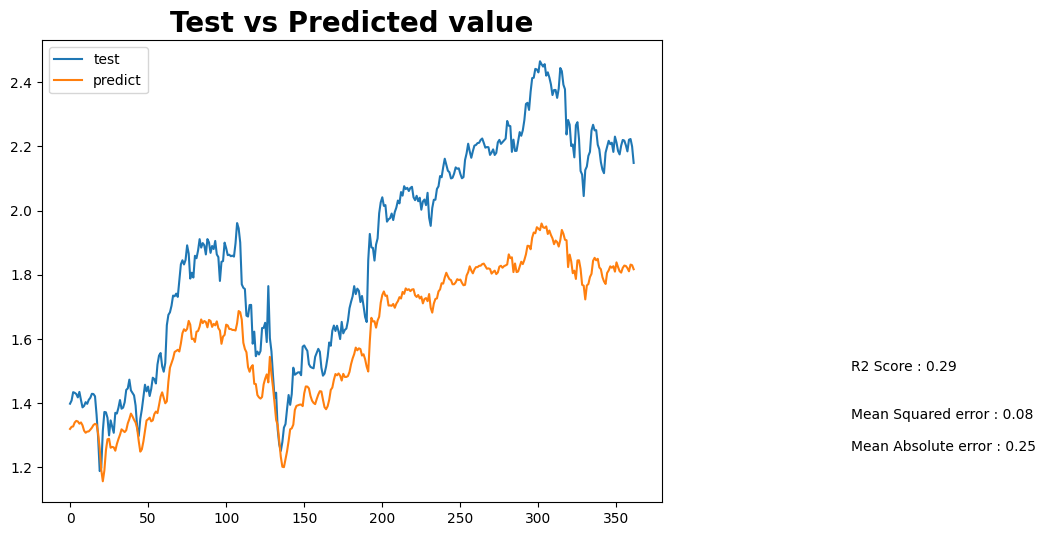

In [ ]:
fig=plt.figure(figsize=(8,6))
plt.title("Test vs Predicted value", size=20, weight='bold')
plt.plot(test)
plt.legend(['test','predict'])
r2=np.round(r2_score(y_test,pred),2)
mse=np.round(mean_squared_error(y_test,pred),2)
mae=np.round(mean_absolute_error(y_test,pred),2)
plt.text(x=500, y=1.5,s='R2 Score : {}'.format(r2))
plt.text(x=500, y=1.35,s='Mean Squared error : {}'.format(mse))
plt.text(x=500, y=1.25,s='Mean Absolute error : {}'.format(mae))